# 07. Slab TE modes: the graphical solution as a lab

Interactive companion to `run.py` (docs/NOTES.md sections 14-23). Everything here is the analytic slab solution in
`slab_te.py` (numpy + scipy root finding), so this notebook runs in the `.venv` kernel without Meep.

The problem (notes 14): symmetric slab, core index $n_1$ for $-d<x<d$, cladding $n_2$ outside, wavelength $\lambda_0$.
Unknowns: the profile $F(x)$ and the propagation constant $\beta$. With $h=\sqrt{n_1^2k_0^2-\beta^2}$ (core) and
$\gamma=\sqrt{\beta^2-n_2^2k_0^2}$ (cladding), matching $E_y$ and $H_z$ at $x=\pm d$ (notes 18-19) gives

* even modes: $h\tan(hd)=\gamma$
* odd modes: $-h\cot(hd)=\gamma$
* always: $(hd)^2+(\gamma d)^2=V^2$, $V=k_0 d\sqrt{n_1^2-n_2^2}$

The circle of radius $V$ is fixed by the geometry and wavelength; each intersection with a tan/cot branch is one guided TE mode.
Move the sliders below and watch the circle grow or shrink: a new mode appears each time $V$ crosses $m\pi/2$.


In [1]:
import sys, pathlib
HERE = pathlib.Path.cwd()
ROOT = HERE.parents[1]
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(HERE))
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from common import REF, use_style, SERIES, PALETTE
import slab_te as st
use_style(dpi=110)
%matplotlib inline
print("REF:", REF.lambda_nm, "nm,", REF.n_si, "/", REF.n_sio2, ", thickness", REF.wg_height_um * 1e3, "nm")

REF: 1310.0 nm, 3.5 / 1.45 , thickness 220.0 nm


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


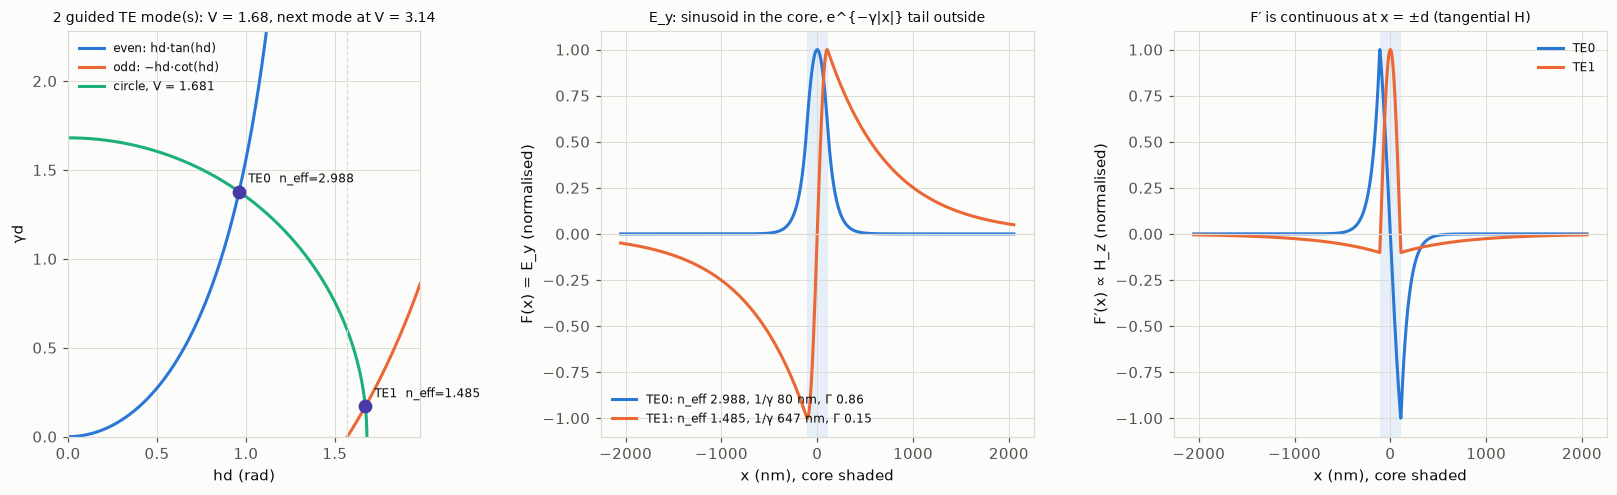

2d = 220 nm, λ0 = 1310 nm, n1 = 3.5, n2 = 1.45: V = 1.6807
TE1 appears above 2d = 205.6 nm at this λ, or below λ0 = 1402 nm at this thickness
 mode      hd      γd  β (rad/µm)    n_eff  1/γ (nm)  λ_g (nm)  θ (deg)      Γ
TE0    0.9616  1.3784     14.3312   2.9879      79.8     438.4    58.62  0.862
TE1    1.6721  0.1699      7.1241   1.4853     647.5     882.0    25.11  0.154


In [2]:
def draw(thickness_nm=220.0, lambda_nm=1310.0, n1=3.50, n2=1.45):
    """Graphical construction (left), F(x) of every guided TE mode (middle), F'(x) ∝ H_z (right)."""
    d = thickness_nm * 1e-3 / 2; lam = lambda_nm * 1e-3
    if n1 <= n2:
        print("n1 must exceed n2 for guiding"); return
    V = st.V_number(d, lam, n1, n2)
    modes = st.solve_te_modes(d, lam, n1, n2)
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
    # --- left: construction
    ax = axs[0]
    umax = V + 0.3; ymax = V + 0.6
    u = np.linspace(1e-3, umax, 4000)
    even = u * np.tan(u); odd = -u / np.tan(u)
    even = np.where((even >= 0) & (even < ymax * 1.05), even, np.nan)
    odd = np.where((odd >= 0) & (odd < ymax * 1.05), odd, np.nan)
    for arr in (even, odd):
        arr[1:][np.abs(np.diff(arr)) > 0.5] = np.nan
    ax.plot(u, even, color=SERIES[0], label="even: hd·tan(hd)")
    ax.plot(u, odd, color=SERIES[1], label="odd: −hd·cot(hd)")
    th = np.linspace(0, np.pi / 2, 300)
    ax.plot(V * np.cos(th), V * np.sin(th), color=SERIES[2], label=f"circle, V = {V:.3f}")
    for md in modes:
        ax.plot(md.hd, md.gd, "o", color=SERIES[3], ms=8, zorder=5)
        ax.annotate(f"TE{md.m}  n_eff={md.neff:.3f}", (md.hd, md.gd), xytext=(6, 6), textcoords="offset points", fontsize=8)
    for k in range(1, int(umax / (np.pi / 2)) + 1):
        ax.axvline(k * np.pi / 2, color=PALETTE["line"], lw=0.8, ls="--")
    ax.set_xlim(0, umax); ax.set_ylim(0, ymax); ax.set_aspect("equal")
    ax.set_xlabel("hd (rad)"); ax.set_ylabel("γd"); ax.legend(fontsize=8)
    ax.set_title(f"{len(modes)} guided TE mode(s): V = {V:.2f}, next mode at V = {len(modes)*np.pi/2:.2f}", fontsize=9)
    # --- middle / right: profiles
    span = max(0.6, 3 * max(md.decay_len_um for md in modes) + d) if modes else 0.6
    x = np.linspace(-span, span, 2001)
    for md in modes:
        F, dF = st.profile(md, x)
        axs[1].plot(x * 1e3, F / abs(F).max(), color=SERIES[md.m % len(SERIES)],
                    label=f"TE{md.m}: n_eff {md.neff:.3f}, 1/γ {md.decay_len_um*1e3:.0f} nm, Γ {md.confinement:.2f}")
        axs[2].plot(x * 1e3, dF / abs(dF).max(), color=SERIES[md.m % len(SERIES)], label=f"TE{md.m}")
    for ax in axs[1:]:
        ax.axvspan(-d * 1e3, d * 1e3, color=SERIES[0], alpha=0.10, lw=0)
        ax.axhline(0, color=PALETTE["line"], lw=0.8); ax.set_xlabel("x (nm), core shaded"); ax.legend(fontsize=8)
    axs[1].set_ylabel("F(x) = E_y (normalised)"); axs[1].set_title("E_y: sinusoid in the core, e^{−γ|x|} tail outside", fontsize=9)
    axs[2].set_ylabel("F′(x) ∝ H_z (normalised)"); axs[2].set_title("F′ is continuous at x = ±d (tangential H)", fontsize=9)
    fig.tight_layout(); plt.show()
    print(f"2d = {thickness_nm:.0f} nm, λ0 = {lambda_nm:.0f} nm, n1 = {n1}, n2 = {n2}: V = {V:.4f}")
    print(f"TE1 appears above 2d = {st.cutoff_thickness_um(1, lam, n1, n2)*1e3:.1f} nm at this λ, or below λ0 = {st.cutoff_wavelength_um(1, d, n1, n2)*1e3:.0f} nm at this thickness")
    print(f"{'mode':>5} {'hd':>7} {'γd':>7} {'β (rad/µm)':>11} {'n_eff':>8} {'1/γ (nm)':>9} {'λ_g (nm)':>9} {'θ (deg)':>8} {'Γ':>6}")
    for md in modes:
        print(f"TE{md.m:<3} {md.hd:7.4f} {md.gd:7.4f} {md.beta_per_um:11.4f} {md.neff:8.4f} {md.decay_len_um*1e3:9.1f} {md.lambda_g_um*1e3:9.1f} {md.theta_deg:8.2f} {md.confinement:6.3f}")

draw()   # the reference case: same numbers as run.py / out/results.json

## Sliders

Things to try (each is one of the *Experiments to try* in the README):

* thickness down to 205 nm: the TE1 dot slides down the circle to $\gamma d=0$ and disappears (cutoff, $V=\pi/2$);
* thickness up to 411 nm: a second even branch enters and TE2 appears;
* wavelength up past 1402 nm at 220 nm: same thing seen from the other side, since $V\propto 1/\lambda_0$;
* $n_2\to 1.0$ (air cladding): larger index contrast, larger $V$, shorter tail;
* $n_1\to 2.0$ (a silicon-nitride-like core): $V$ collapses and the mode spreads far into the cladding.


In [3]:
from ipywidgets import interact, FloatSlider
interact(draw,
         thickness_nm=FloatSlider(value=220, min=50, max=800, step=5, description="2d (nm)", continuous_update=False),
         lambda_nm=FloatSlider(value=1310, min=1000, max=2000, step=10, description="λ0 (nm)", continuous_update=False),
         n1=FloatSlider(value=3.50, min=1.6, max=4.0, step=0.01, description="n1 core", continuous_update=False),
         n2=FloatSlider(value=1.45, min=1.0, max=3.0, step=0.01, description="n2 clad", continuous_update=False));

interactive(children=(FloatSlider(value=220.0, continuous_update=False, description='2d (nm)', max=800.0, min=…

## Cutoff map: number of guided TE modes versus thickness and wavelength

$N_{TE}=\lfloor 2V/\pi\rfloor+1$. The 220 nm / 1310 nm design point sits just inside the two-mode region for the *slab*
(the vertical odd mode TE1 has $n_{eff}=1.4853$, only 0.035 above the cladding index 1.45). In the real 500 nm wide strip the lateral
confinement is expected to push that vertical odd mode below cutoff; whether the strip supports a *lateral* higher-order mode
at 500 nm width is a separate question that the 2-D solvers of experiment 08 answer.


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


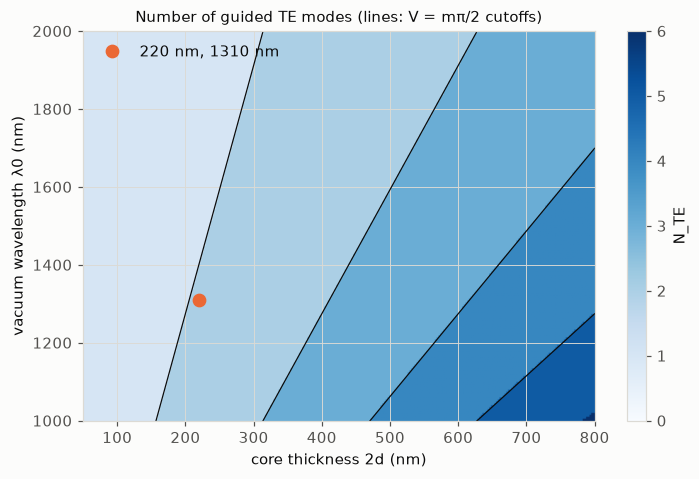

N_TE at the design point: 2


In [4]:
T = np.linspace(50, 800, 301); L = np.linspace(1000, 2000, 201)
TT, LL = np.meshgrid(T, L)
N = np.floor(2 * st.V_number(TT * 1e-3 / 2, LL * 1e-3, REF.n_si, REF.n_sio2) / np.pi) + 1
fig, ax = plt.subplots(figsize=(7.5, 4.6))
im = ax.imshow(N, extent=[T[0], T[-1], L[0], L[-1]], origin="lower", aspect="auto", cmap="Blues", vmin=0, vmax=N.max())
for m in range(1, 5):
    ax.plot(T, 2 * T * np.sqrt(REF.n_si**2 - REF.n_sio2**2) / m, color=PALETTE["ink"], lw=0.8)
ax.plot([220], [1310], "o", color=SERIES[1], ms=8, label="220 nm, 1310 nm")
ax.set_ylim(L[0], L[-1]); ax.set_xlabel("core thickness 2d (nm)"); ax.set_ylabel("vacuum wavelength λ0 (nm)")
ax.set_title("Number of guided TE modes (lines: V = mπ/2 cutoffs)", fontsize=10); ax.legend()
fig.colorbar(im, ax=ax, label="N_TE"); plt.show()
print("N_TE at the design point:", int(N[np.argmin(abs(L-1310)), np.argmin(abs(T-220))]))

## n_eff versus n_g for the slab, and why the ring formulas use n_g

$n_g = n_{eff} - \lambda_0\,dn_{eff}/d\lambda_0$ (notes 22). Below, both are computed for TE0 across the O-band with fixed material
indices (waveguide dispersion only). The FSR of a ring is $c/(n_g L)$, so the capstone FSR (10.3 nm) depends on $n_g$, not on $n_{eff}$.
The thermal shift is usually written $d\lambda_r/dT = (\lambda_0/n_g)\,dn_{eff}/dT$, which looks like it depends on $n_g$ too, but
perturbation theory gives $\partial n_{eff}/\partial n_1 = (n_g/n_1)\,\Gamma_E$ with $\Gamma_E$ the fraction of the electric energy
in silicon, so $n_g$ cancels: $d\lambda_r/dT = \lambda_0\,[\Gamma_E\,(dn_1/dT)/n_1 + (1-\Gamma_E)\,(dn_2/dT)/n_2]$. The 50 pm/K
reference number is therefore set by $\Gamma_E$ alone (see `run.py` and the README), and neither $n_{eff}$ nor $n_g$ enters it.


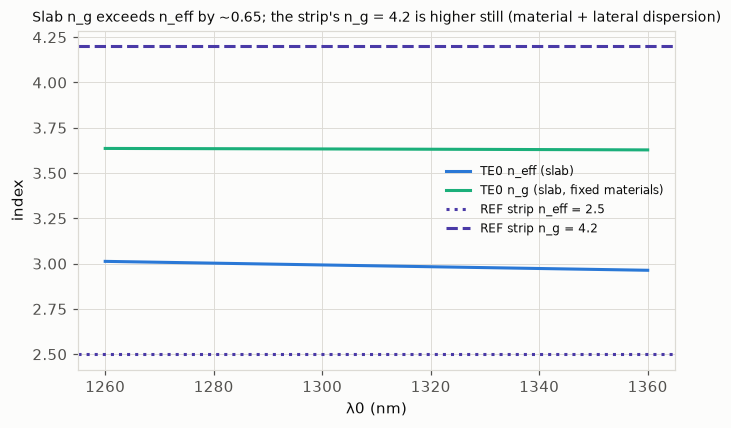

at 1310 nm: slab n_eff = 2.9879, slab n_g = 3.6323
FSR with slab n_g: 11.93 nm; with REF n_g 4.2: 10.32 nm (REF fsr_nm = 10.3)
resonance order m = n_eff L / λ0: slab 90.3, REF n_eff 2.5 -> 75.6 (an integer in a real ring; it fixes λ_r, not the spacing)


In [5]:
lams = np.linspace(1.26, 1.36, 21)
neffs = np.array([st.solve_te_modes(0.11, l, REF.n_si, REF.n_sio2)[0].neff for l in lams])
ngs = np.array([st.group_index(0.11, l, REF.n_si, REF.n_sio2, 0) for l in lams])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lams * 1e3, neffs, color=SERIES[0], label="TE0 n_eff (slab)")
ax.plot(lams * 1e3, ngs, color=SERIES[2], label="TE0 n_g (slab, fixed materials)")
ax.axhline(REF.neff, color=SERIES[3], ls=":", label=f"REF strip n_eff = {REF.neff}")
ax.axhline(REF.ng, color=SERIES[3], ls="--", label=f"REF strip n_g = {REF.ng}")
ax.set_xlabel("λ0 (nm)"); ax.set_ylabel("index"); ax.legend(fontsize=8)
ax.set_title("Slab n_g exceeds n_eff by ~0.65; the strip's n_g = 4.2 is higher still (material + lateral dispersion)", fontsize=9)
plt.show()
i = np.argmin(abs(lams - 1.31))
L_rt = REF.round_trip_um
print(f"at 1310 nm: slab n_eff = {neffs[i]:.4f}, slab n_g = {ngs[i]:.4f}")
print(f"FSR with slab n_g: {1.31**2/(ngs[i]*L_rt)*1e3:.2f} nm; with REF n_g 4.2: {1.31**2/(REF.ng*L_rt)*1e3:.2f} nm (REF fsr_nm = {REF.fsr_nm})")
print(f"resonance order m = n_eff L / λ0: slab {neffs[i]*L_rt/1.31:.1f}, REF n_eff 2.5 -> {REF.neff*L_rt/1.31:.1f} (an integer in a real ring; it fixes λ_r, not the spacing)")